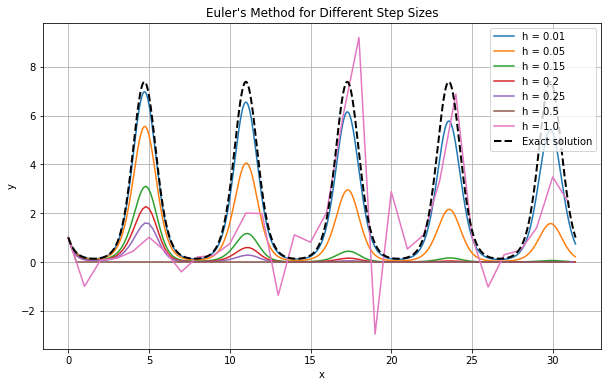

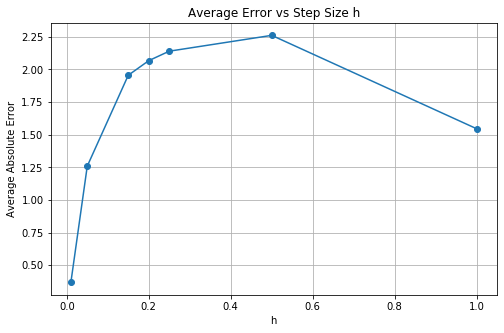

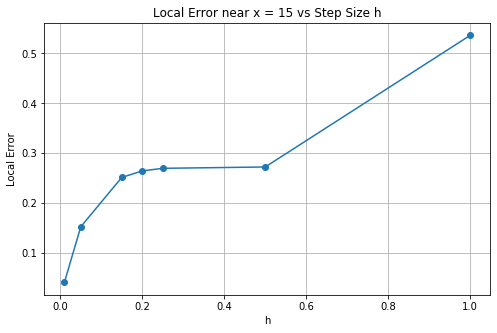

In [17]:
import numpy as np
import matplotlib.pyplot as plt

#reference:chatgpt, asked how to error check,local error absolute error,stability condiiton check
#y' = -2y cos(x), y(0) = 1
def f(x, y):
    return -2 * y * np.cos(x)

#exact solution for error checking
def y_exact(x):
    return np.exp(-2 * np.sin(x))

#euler's Method
def euler_method(h, x0=0.0, x_end=10*np.pi, y0=1.0):
    x_values = [x0]
    y_values = [y0]

    x = x0
    y = y0

    while x + h <= x_end + 1e-12:
        y = y + h * f(x, y)
        x = x + h
        x_values.append(x)
        y_values.append(y)

    return np.array(x_values), np.array(y_values)

#step sizes
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 1.0]

avg_y_list = []
avg_error_list = []
local_error_list = []
x_near_15_list = []
y_near_15_list = []

#plot 1: Euler solutions for each h
plt.figure(figsize=(10, 6))

for h in h_values:
    x_vals, y_vals = euler_method(h)
    y_true = y_exact(x_vals)

    #average of y-values for this run
    avg_y = np.mean(y_vals)
    avg_y_list.append(avg_y)

    #average absolute error over the whole run
    avg_error = np.mean(np.abs(y_vals - y_true))
    avg_error_list.append(avg_error)

    #Local error at x ~ 15
    idx_15 = np.argmin(np.abs(x_vals - 15))
    x_near_15 = x_vals[idx_15]
    y_near_15 = y_vals[idx_15]
    true_near_15 = y_exact(x_near_15)
    local_error = abs(y_near_15 - true_near_15)

    x_near_15_list.append(x_near_15)
    y_near_15_list.append(y_near_15)
    local_error_list.append(local_error)

    plt.plot(x_vals, y_vals, label=f"h = {h}")

x_fine = np.linspace(0, 10*np.pi, 2000)
plt.plot(x_fine, y_exact(x_fine), 'k--', linewidth=2, label='Exact solution')

plt.title("Euler's Method for Different Step Sizes")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

#plot 2: Average error vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_error_list, marker='o')
plt.title("Average Error vs Step Size h")
plt.xlabel("h")
plt.ylabel("Average Absolute Error")
plt.grid(True)
plt.show()

#plot 3: Local error near x = 15 vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, local_error_list, marker='o')
plt.title("Local Error near x = 15 vs Step Size h")
plt.xlabel("h")
plt.ylabel("Local Error")
plt.grid(True)
plt.show()

In [18]:
""""Using the slope at the current position and moving forward, Euler's Method approximates the solution. 
Smaller step sizes provide more precision because the slope is only used at the start of each step.
For this reason, compared to curves with bigger h, the curve for h=0.01 closely resembles the correct answer. 
Because Euler's Method global error is proportional to h and its local error is proportional to h^2, lowering 
h lowers overall error. Because larger steps result in a rougher approximation, the error grows as h increases 
in the average error vs. h figure. Smaller h values yield results that are closer to the exact value for the 
local error at x=15."""

'"Using the slope at the current position and moving forward, Euler\'s Method approximates the solution. \nSmaller step sizes provide more precision because the slope is only used at the start of each step.\nFor this reason, compared to curves with bigger h, the curve for h=0.01\xa0closely resembles the correct answer. \nBecause Euler\'s Method global error is proportional to h\xa0and its local error is proportional to h^2, lowering \nh lowers overall error. Because larger steps result in a rougher approximation, the error grows as h increases \nin the average error vs. h figure. Smaller h values yield results that are closer to the exact value for the \nlocal error at x=15.'

In [19]:
print("Stability Condition Check")

for h in h_values:
    x_vals = np.linspace(0, 10*np.pi, 1000)
    stability_vals = np.abs(1 - 2*h*np.cos(x_vals))
    
    is_stable = np.all(stability_vals < 1)
    
    print(f"h = {h:.2f} --> Stable: {is_stable}")

Stability Condition Check
h = 0.01 --> Stable: False
h = 0.05 --> Stable: False
h = 0.15 --> Stable: False
h = 0.20 --> Stable: False
h = 0.25 --> Stable: False
h = 0.50 --> Stable: False
h = 1.00 --> Stable: False


In [20]:
"""Because the coefficient depends on x, the differential equation y′ = −2ycos(x) 
is not a conventional linear test equation of the form y′ = λy with constant λ. 
Nevertheless, by treating it as a test equation with variable coefficient 𝜆(𝑥) = −2cos⁡(𝑥),
we can carry out a local stability study. Euler's technique yields the amplification 
factor 1+hλ(x n) = 1−2hcos(x n). Therefore, the stability requirement is |1−2hcos⁡(x n)|less than equal to 1, 
which reduces to 0≤ hcos⁡(x n)≤1. Stability fluctuates throughout the interval because cos (x) changes sign. 
Stability needs h≤1/cos(x) when cos⁡(𝑥) > 0, otherwise, instability may arise."""

"Because the coefficient depends on x, the differential equation y′ = −2ycos(x) \nis not a conventional linear test equation of the form y′ = λy with constant λ. \nNevertheless, by treating it as a test equation with variable coefficient 𝜆(𝑥) = −2cos\u2061(𝑥),\nwe can carry out a local stability study. Euler's technique yields the amplification \nfactor\xa01+hλ(x n) = 1−2hcos(x n). Therefore, the stability requirement is |1−2hcos\u2061(x n)|less than equal to 1, \nwhich reduces to 0≤ hcos\u2061(x n)≤1. Stability fluctuates throughout the interval because cos (x) changes sign. \nStability needs h≤1/cos(x) when cos\u2061(𝑥) > 0,\xa0otherwise, instability may arise."